# Inflation Trend Analysis: Pakistan & Selected South Asian Countries (2000–2025)

## Project Overview

This project analyzes inflation and consumer price trends using Python.

The analysis focuses primarily on Pakistan and compares inflation trends
across selected South Asian countries to identify important economic
patterns and differences.

## Objectives

- Analyze inflation trends over time
- Identify periods of high inflation
- Compare inflation rates across selected South Asian countries
- Measure relationships between inflation rates across countries
- Examine average inflation and inflation volatility
- Generate meaningful economic insights from the data

## Dataset

**Source:** World Bank

**Indicator:** Consumer Price Index (2010 = 100)

**Indicator Code:** FP.CPI.TOTL

**Countries:** Pakistan, India, Bangladesh, Sri Lanka, Nepal

**Analysis Period:** 2000–2025

The annual inflation rate is calculated from year-over-year percentage
changes in the Consumer Price Index (CPI).

## Methodology

1. Loaded the World Bank CPI dataset using Pandas.
2. Removed an unnecessary column from the downloaded dataset.
3. Selected Pakistan, India, Bangladesh, Sri Lanka, and Nepal.
4. Restricted the analysis to 2000–2025.
5. Reshaped the dataset from wide format to long format using `melt()`.
6. Calculated annual inflation using year-over-year percentage change
   in CPI.
7. Performed exploratory data analysis using Pandas.
8. Compared average inflation, minimum inflation, maximum inflation,
   and inflation volatility across countries.
9. Analyzed Pakistan's high-inflation periods.
10. Examined relationships between countries using correlation analysis.

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline

print("Libraries loaded successfully!")

Libraries loaded successfully!


In [2]:
print("Pandas version:", pd.__version__)
print("NumPy version:", np.__version__)

Pandas version: 2.3.1
NumPy version: 2.3.2


In [3]:
df=pd.read_csv("Inflation_Data.csv", skiprows=4)


In [4]:
df.columns

Index(['Country Name', 'Country Code', 'Indicator Name', 'Indicator Code',
       '1960', '1961', '1962', '1963', '1964', '1965', '1966', '1967', '1968',
       '1969', '1970', '1971', '1972', '1973', '1974', '1975', '1976', '1977',
       '1978', '1979', '1980', '1981', '1982', '1983', '1984', '1985', '1986',
       '1987', '1988', '1989', '1990', '1991', '1992', '1993', '1994', '1995',
       '1996', '1997', '1998', '1999', '2000', '2001', '2002', '2003', '2004',
       '2005', '2006', '2007', '2008', '2009', '2010', '2011', '2012', '2013',
       '2014', '2015', '2016', '2017', '2018', '2019', '2020', '2021', '2022',
       '2023', '2024', '2025', 'Unnamed: 70'],
      dtype='object')

In [5]:
df=df.drop(columns=["Unnamed: 70"])

In [6]:
df.shape

(265, 70)

In [7]:
df.head()

,Country Name,Country Code,Indicator Name,Indicator Code,1960,1961,1962,1963,1964,1965,...,2016,2017,2018,2019,2020,2021,2022,2023,2024,2025
0,Aruba,ABW,Consumer price index (2010 = 100),FP.CPI.TOTL,NaN,NaN,NaN,NaN,NaN,NaN,...,102.438495,101.385139,105.061406,109.534355,NaN,NaN,NaN,NaN,NaN,NaN
1,Africa Eastern and Southern,AFE,Consumer price index (2010 = 100),FP.CPI.TOTL,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,Afghanistan,AFG,Consumer price index (2010 = 100),FP.CPI.TOTL,NaN,NaN,NaN,NaN,NaN,NaN,...,138.708666,145.610741,146.522482,149.895975,158.292980,166.418480,189.237953,180.448401,168.536667,NaN
3,Africa Western and Central,AFW,Consumer price index (2010 = 100),FP.CPI.TOTL,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,Angola,AGO,Consumer price index (2010 = 100),FP.CPI.TOTL,NaN,NaN,NaN,NaN,NaN,NaN,...,208.726444,271.019766,324.218068,379.597607,464.139837,583.675779,708.321436,804.965533,1032.291783,1240.422657


In [8]:
countries=["Pakistan","India","Bangladesh","Sri Lanka","Nepal"]

In [9]:
df_selected=df[df["Country Name"].isin(countries)].copy()

In [10]:
df_selected[["Country Name", "Country Code"]]

,Country Name,Country Code
20,Bangladesh,BGD
108,India,IND
137,Sri Lanka,LKA
177,Nepal,NPL
183,Pakistan,PAK


In [11]:
df_selected = df_selected[
    ["Country Name", "Country Code"] +
    [str(year) for year in range(2000, 2026)]
]

In [12]:
df_selected

,Country Name,Country Code,2000,2001,2002,2003,2004,2005,2006,2007,...,2016,2017,2018,2019,2020,2021,2022,2023,2024,2025
20,Bangladesh,BGD,53.909144,54.991194,56.823812,60.044987,64.600923,69.153103,73.831491,80.555314,...,152.529140,161.226459,170.164243,179.679822,189.905535,200.437039,215.864587,237.199570,262.024279,285.000567
108,India,IND,54.338322,56.391926,58.815173,61.053595,63.353638,66.043851,69.872099,74.324964,...,154.054013,159.181198,165.451069,171.621576,182.988823,192.378725,205.266241,216.862025,227.603278,233.063138
137,Sri Lanka,LKA,36.480029,41.645038,45.622569,48.503469,52.178055,58.251417,64.088316,74.241259,...,136.566581,147.087858,150.228239,155.528883,165.100045,176.681451,264.529416,308.285688,306.962032,292.338789
177,Nepal,NPL,55.753509,57.252332,58.986734,62.353113,64.125070,68.508874,73.249918,74.912119,...,165.784441,170.388341,177.896663,187.798677,197.294451,205.436334,221.193724,236.933587,248.034155,254.615351
183,Pakistan,PAK,43.411698,44.778412,46.251776,47.599615,51.143228,55.778506,60.196769,64.770931,...,150.752541,156.911346,164.879394,182.320387,200.078604,219.078900,262.618334,343.421079,386.803857,400.518189


## Reshape the data

In [13]:
df_long=df_selected.melt(
    id_vars=["Country Name","Country Code"],
    var_name="Year",
    value_name="CPI"
)

In [14]:
df_long.head()

,Country Name,Country Code,Year,CPI
0,Bangladesh,BGD,2000,53.909144
1,India,IND,2000,54.338322
2,Sri Lanka,LKA,2000,36.480029
3,Nepal,NPL,2000,55.753509
4,Pakistan,PAK,2000,43.411698


## Clean the Year column

In [15]:
df_long["Year"] = pd.to_numeric(
    df_long["Year"]
)

In [16]:
df_long.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 130 entries, 0 to 129
Data columns (total 4 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Country Name  130 non-null    object 
 1   Country Code  130 non-null    object 
 2   Year          130 non-null    int64  
 3   CPI           130 non-null    float64
dtypes: float64(1), int64(1), object(2)
memory usage: 4.2+ KB


## Check the missing values



In [17]:
df_long.isnull().sum()

Country Name    0
Country Code    0
Year            0
CPI             0
dtype: int64

## Calculate inflation

In [18]:
df_long["Inflation"]=(
    df_long.groupby("Country Name")["CPI"]
        .pct_change() * 100
)

In [19]:
df_long.head(15)

,Country Name,Country Code,Year,CPI,Inflation
0,Bangladesh,BGD,2000,53.909144,NaN
1,India,IND,2000,54.338322,NaN
2,Sri Lanka,LKA,2000,36.480029,NaN
3,Nepal,NPL,2000,55.753509,NaN
4,Pakistan,PAK,2000,43.411698,NaN
5,Bangladesh,BGD,2001,54.991194,2.007174
6,India,IND,2001,56.391926,3.779293
7,Sri Lanka,LKA,2001,41.645038,14.158456
8,Nepal,NPL,2001,57.252332,2.688304
9,Pakistan,PAK,2001,44.778412,3.148261


## Chart 1: Inflation Trends in Selected South Asian Countries

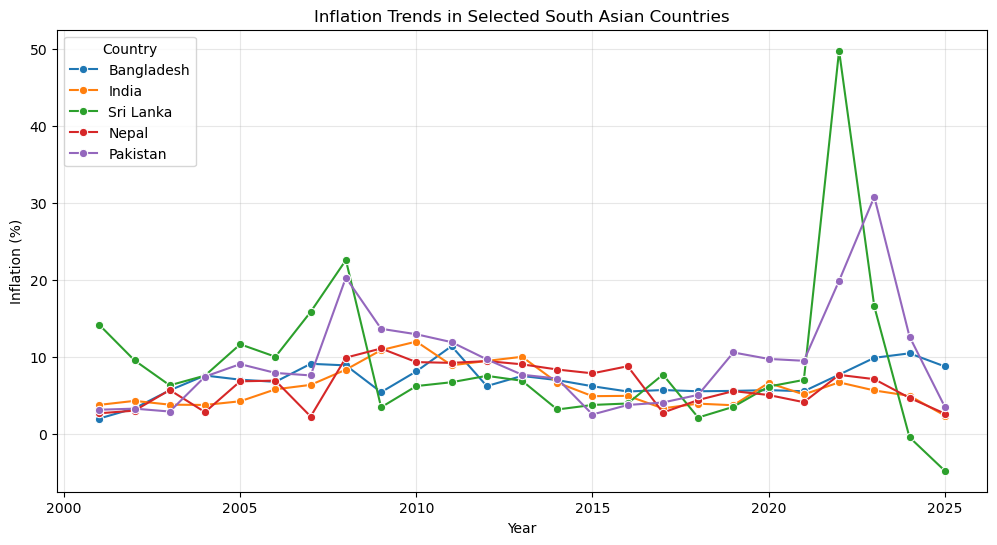

In [20]:
plt.figure(figsize=(12, 6))

sns.lineplot(
    data=df_long,
    x="Year",
    y="Inflation",
    hue="Country Name",
    marker="o"
)

plt.title("Inflation Trends in Selected South Asian Countries")
plt.xlabel("Year")
plt.ylabel("Inflation (%)")
plt.legend(title="Country")
plt.grid(alpha=0.3)

plt.show()

## Highest inflation for each country

In [21]:
highest_inflation=(
    df_long.loc[df_long.groupby("Country Name")["Inflation"].idxmax()
        ]
    [["Country Name","Year","Inflation"]].sort_values("Inflation",ascending=False)
)

highest_inflation

,Country Name,Year,Inflation
112,Sri Lanka,2022,49.721102
119,Pakistan,2023,30.768128
51,India,2010,11.989390
55,Bangladesh,2011,11.395165
48,Nepal,2009,11.094824


## Key Findings: Peak Inflation

- Sri Lanka recorded the highest inflation rate among the selected
  South Asian countries, reaching approximately 49.72% in 2022.

- Pakistan recorded its highest inflation rate at approximately 30.77%
  in 2023.

- India recorded its highest inflation rate of approximately 11.99%
  in 2010.

- Bangladesh reached a peak inflation rate of approximately 11.40%
  in 2011.

- Nepal recorded its highest inflation rate of approximately 11.09%
  in 2009.

- The results show substantial differences in the timing and magnitude
  of inflation peaks across the selected countries.

### Average Inflation and Inflation Volitilty

In [22]:
country_summary = (
    df_long.groupby("Country Name")["Inflation"]
    .agg(
        Average_Inflation="mean",
        Inflation_Volatility="std",
        Minimum_Inflation="min",
        Maximum_Inflation="max"
    )
    .round(2)
    .sort_values("Average_Inflation", ascending=False)
)

country_summary

,Average_Inflation,Inflation_Volatility,Minimum_Inflation,Maximum_Inflation
Country Name,,,,
Pakistan,9.47,6.55,2.53,30.77
Sri Lanka,9.08,10.20,-4.76,49.72
Bangladesh,6.91,2.13,2.01,11.40
Nepal,6.30,2.73,2.27,11.09
India,6.03,2.57,2.40,11.99


## Country-Level Inflation Analysis

The descriptive analysis reveals substantial differences in inflation
patterns across the selected South Asian economies.

### Key Findings

1. Pakistan recorded the highest average inflation rate among the
   selected countries at 9.47% during the study period.

2. Sri Lanka had an average inflation rate of 9.08%, but its inflation
   volatility was the highest at 10.20, indicating substantially larger
   fluctuations over time.

3. Sri Lanka also recorded the highest maximum inflation rate at 49.72%
   in 2022, demonstrating an exceptional inflation episode.

4. Pakistan recorded a maximum inflation rate of 30.77% in 2023 and
   had the second-highest inflation volatility at 6.55.

5. India had the lowest average inflation rate among the five countries
   at 6.03%, while Bangladesh and Nepal recorded average inflation rates
   of 6.91% and 6.30%, respectively.

6. Sri Lanka's minimum inflation rate was -4.76%, indicating that the
   country experienced a period of negative annual CPI growth during
   the study period.

### Average Inflation vs Inflation Volatility

Average inflation measures the typical level of inflation over the
study period, while inflation volatility measures how much inflation
fluctuated around its average.

Therefore, a country can have a relatively high average inflation rate
without necessarily having the largest fluctuations. In this analysis,
Pakistan has the highest average inflation, whereas Sri Lanka has the
highest inflation volatility.

## Chart 2: Comparison Of Average Inflation 

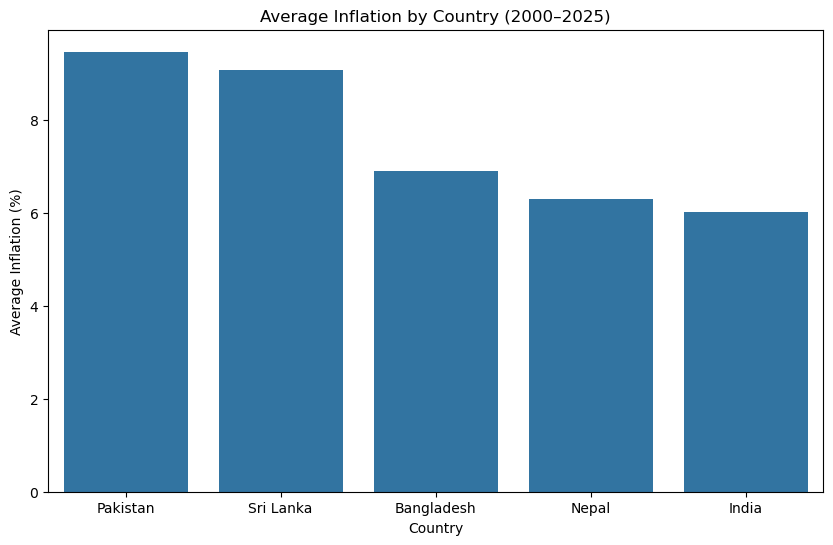

In [23]:
summary_reset = country_summary.reset_index()

plt.figure(figsize=(10, 6))

sns.barplot(
    data=summary_reset,
    x="Country Name",
    y="Average_Inflation"
)

plt.title("Average Inflation by Country (2000–2025)")
plt.xlabel("Country")
plt.ylabel("Average Inflation (%)")
plt.xticks(rotation=0)

plt.show()

## Chart 3: Inflation Volatility

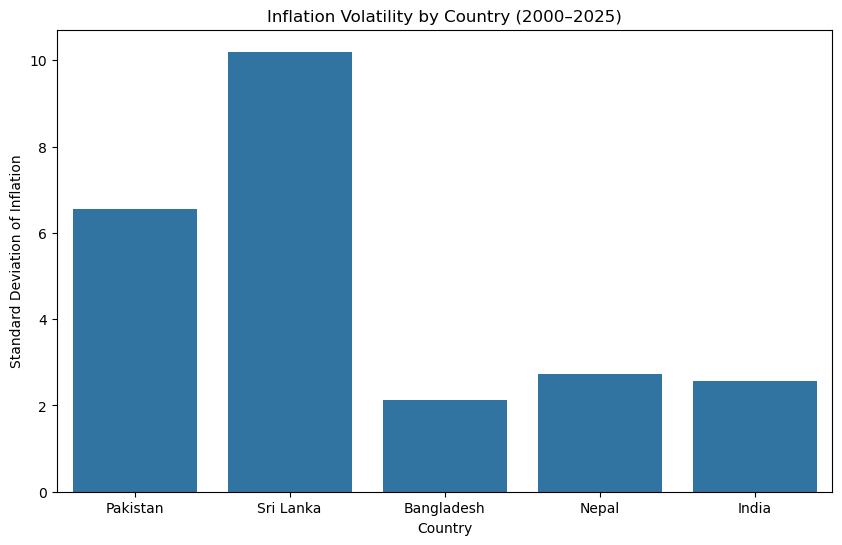

In [24]:
plt.figure(figsize=(10, 6))

sns.barplot(
    data=summary_reset,
    x="Country Name",
    y="Inflation_Volatility"
)

plt.title("Inflation Volatility by Country (2000–2025)")
plt.xlabel("Country")
plt.ylabel("Standard Deviation of Inflation")

plt.show()

## Pakistan's Inflation Analysis (2000-2025)

In [25]:
pakistan=df_long[
    df_long["Country Name"]== "Pakistan"
    ].copy()

pakistan.head()

,Country Name,Country Code,Year,CPI,Inflation
4,Pakistan,PAK,2000,43.411698,NaN
9,Pakistan,PAK,2001,44.778412,3.148261
14,Pakistan,PAK,2002,46.251776,3.290345
19,Pakistan,PAK,2003,47.599615,2.914135
24,Pakistan,PAK,2004,51.143228,7.444625


In [26]:
pakistan.describe()

,Year,CPI,Inflation
count,26.000000,26.000000,25.000000
mean,2012.500000,146.215816,9.473029
std,7.648529,103.708784,6.549238
min,2000.000000,43.411698,2.529328
25%,2006.250000,61.340309,4.085374
50%,2012.500000,127.473348,7.921084
75%,2018.750000,177.960138,11.916093
max,2025.000000,400.518189,30.768128


In [27]:
pakistan.sort_values(
    "Inflation",
    ascending=False
).head(10)

,Country Name,Country Code,Year,CPI,Inflation
119,Pakistan,PAK,2023,343.421079,30.768128
44,Pakistan,PAK,2008,77.910441,20.286121
114,Pakistan,PAK,2022,262.618334,19.873860
49,Pakistan,PAK,2009,88.543474,13.647765
54,Pakistan,PAK,2010,100.000000,12.938871
124,Pakistan,PAK,2024,386.803857,12.632532
59,Pakistan,PAK,2011,111.916093,11.916093
99,Pakistan,PAK,2019,182.320387,10.578031
104,Pakistan,PAK,2020,200.078604,9.740116
64,Pakistan,PAK,2012,122.752203,9.682352


### Chart 4:Pakistan inflation chart

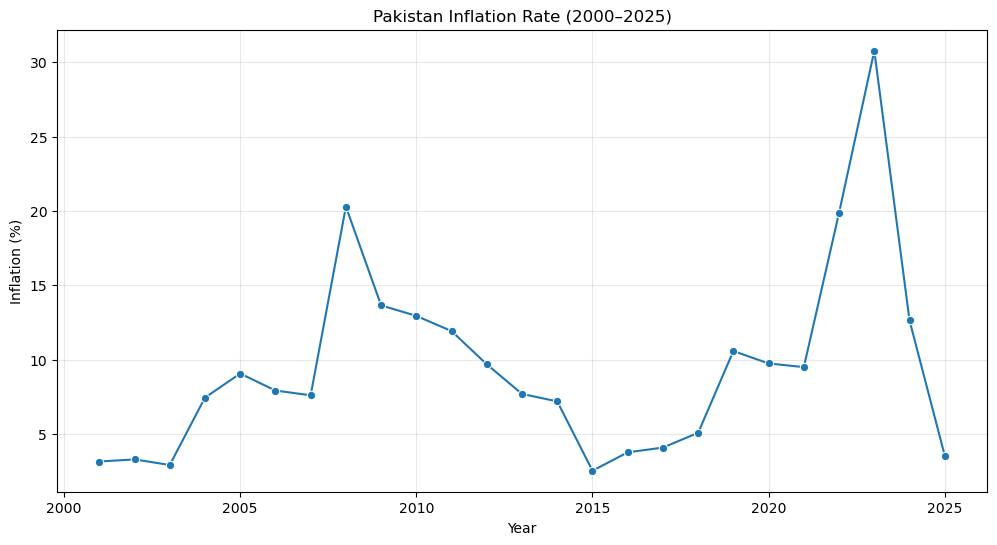

In [28]:
plt.figure(figsize=(12,6))

sns.lineplot(
    data=pakistan,
    x="Year",
    y="Inflation",
    marker="o"
)

plt.title("Pakistan Inflation Rate (2000–2025)")
plt.xlabel("Year")
plt.ylabel("Inflation (%)")
plt.grid(alpha=0.3)

plt.show()

## High-inflation years in Pakistan:

In [29]:
pakistan_high_inflation=pakistan[
    pakistan["Inflation"]>10
    ].copy()

pakistan_high_inflation[
    ["Year","Inflation"]].sort_values("Inflation",ascending=False)

,Year,Inflation
119,2023,30.768128
44,2008,20.286121
114,2022,19.873860
49,2009,13.647765
54,2010,12.938871
124,2024,12.632532
59,2011,11.916093
99,2019,10.578031


## Pakistan: High Inflation Episodes

The analysis identifies eight years between 2000 and 2025 in which
Pakistan's annual inflation rate exceeded 10%.

The highest inflation rate occurred in 2023, reaching approximately
30.77%. This was followed by 2008 at 20.29% and 2022 at 19.87%.

Other periods of double-digit inflation occurred in 2009, 2010, 2011,
2019, and 2024.

The results indicate that Pakistan experienced several distinct periods
of elevated inflation rather than consistently high inflation throughout
the entire study period.

The 2022–2024 period is particularly notable because inflation remained
elevated across three consecutive years, with the peak occurring in
2023.

### Chart 5: Pakistan's High Inflation Episodes

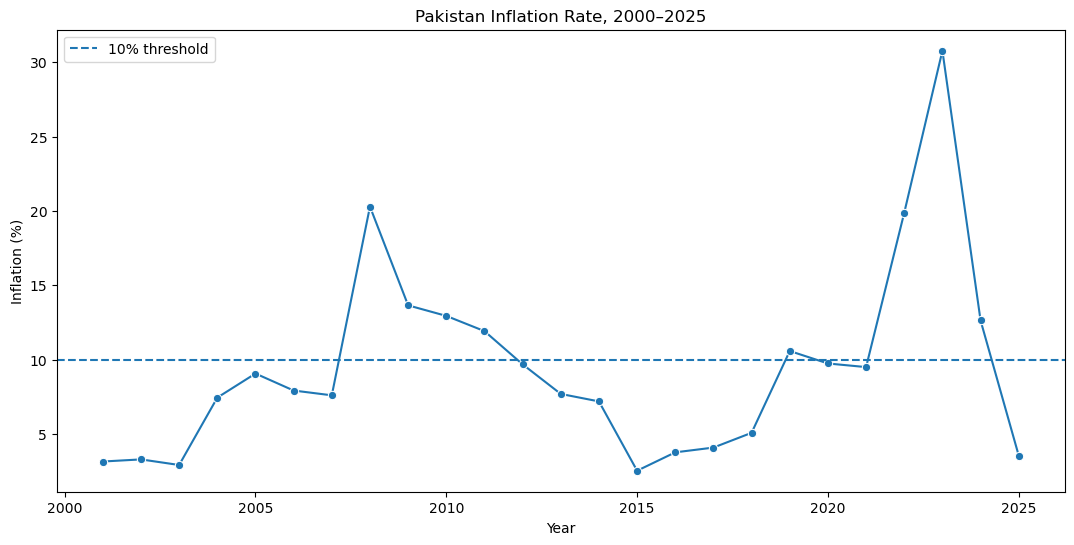

In [30]:
plt.figure(figsize=(13, 6))

sns.lineplot(
    data=pakistan,
    x="Year",
    y="Inflation",
    marker="o"
)

plt.axhline(
    y=10,
    linestyle="--",
    label="10% threshold"
)

plt.title("Pakistan Inflation Rate, 2000–2025")
plt.xlabel("Year")
plt.ylabel("Inflation (%)")
plt.legend()

plt.show()

In [31]:
high_inflation_count=(
    pakistan["Inflation"]>10
).sum()

high_inflation_count

np.int64(8)

In [32]:
total_years = pakistan["Inflation"].notna().sum()

high_inflation_percentage = (
    high_inflation_count / total_years
) * 100

round(high_inflation_percentage, 2)

np.float64(32.0)

In [33]:
def inflation_category(rate):
    if rate <5:
        return "Low"
    elif rate <=10:
        return "Moderate"
    else:
        return "High"

pakistan["Inflation_Category"]=pakistan["Inflation"].apply(
    inflation_category)
    

In [34]:
pakistan[["Year","Inflation","Inflation_Category"]].head(15)

,Year,Inflation,Inflation_Category
4,2000,NaN,High
9,2001,3.148261,Low
14,2002,3.290345,Low
19,2003,2.914135,Low
24,2004,7.444625,Moderate
29,2005,9.063327,Moderate
34,2006,7.921084,Moderate
39,2007,7.598684,Moderate
44,2008,20.286121,High
49,2009,13.647765,High


In [35]:
pakistan["Inflation_Category"].value_counts()

Inflation_Category
Moderate    10
High         9
Low          7
Name: count, dtype: int64

In [36]:
pakistan["Inflation_Category"].value_counts(
    normalize=True
).mul(100).round(2)

Inflation_Category
Moderate    38.46
High        34.62
Low         26.92
Name: proportion, dtype: float64

### Chart 6: Pakistan Inflation Categories (2000–2025)

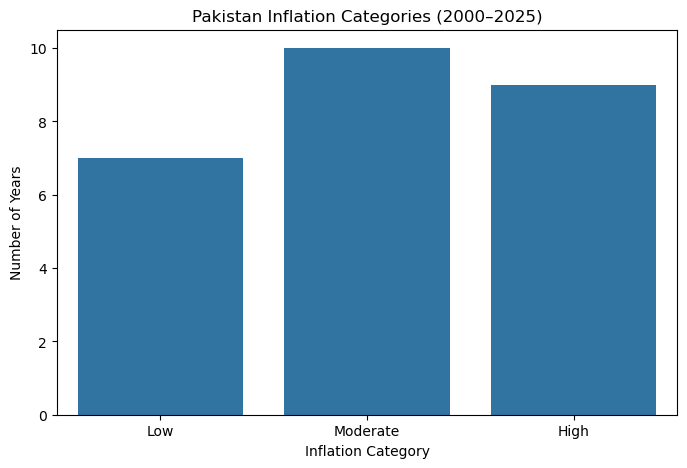

In [37]:
category_counts= (
    pakistan["Inflation_Category"]
    .value_counts()
    .reindex(["Low","Moderate","High"])
)

plt.figure(figsize=(8, 5))

sns.barplot(
    x=category_counts.index,
    y=category_counts.values
)

plt.title("Pakistan Inflation Categories (2000–2025)")
plt.xlabel("Inflation Category")
plt.ylabel("Number of Years")

plt.show()

## Correlation analysis:

In [38]:
inflation_pivot=df_long.pivot(
    index="Year",
    columns="Country Name",
    values="Inflation"
)

inflation_pivot.head()

Country Name,Bangladesh,India,Nepal,Pakistan,Sri Lanka
Year,,,,,
2000,NaN,NaN,NaN,NaN,NaN
2001,2.007174,3.779293,2.688304,3.148261,14.158456
2002,3.332565,4.297152,3.029399,3.290345,9.551032
2003,5.668708,3.805859,5.707009,2.914135,6.314638
2004,7.587536,3.767252,2.841811,7.444625,7.575926


In [39]:
correlation_matrix=inflation_pivot.corr()
correlation_matrix.round(2)

Country Name,Bangladesh,India,Nepal,Pakistan,Sri Lanka
Country Name,,,,,
Bangladesh,1.00,0.29,0.25,0.54,0.08
India,0.29,1.00,0.77,0.40,0.14
Nepal,0.25,0.77,1.00,0.41,0.12
Pakistan,0.54,0.40,0.41,1.00,0.51
Sri Lanka,0.08,0.14,0.12,0.51,1.00


## Chart 7:Correlation heatmap

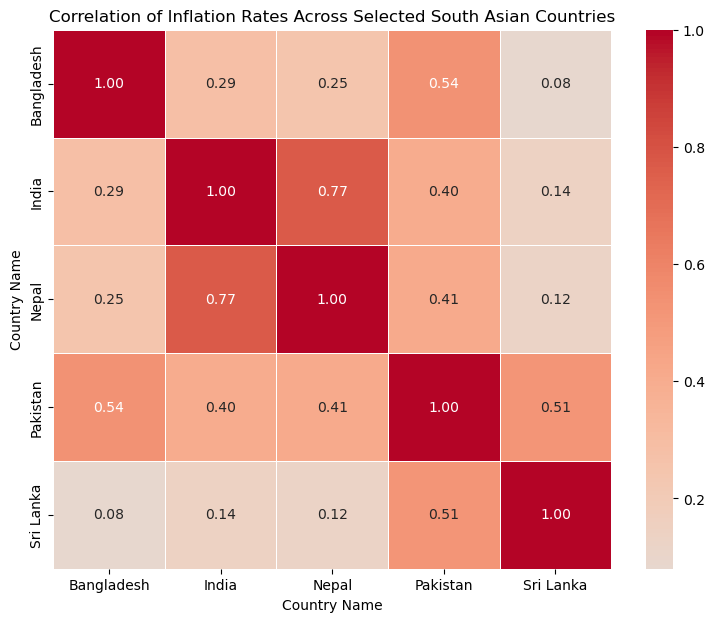

In [40]:
plt.figure(figsize=(9,7))

sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    linewidths=0.5
)

plt.title("Correlation of Inflation Rates Across Selected South Asian Countries")
plt.show()

## Relationship Between Inflation Rates

Correlation analysis was used to examine whether inflation rates in the
selected South Asian countries tended to move together during the
2000–2025 period.

The correlation matrix shows the strength and direction of the
relationship between inflation rates across countries.

### Key Observations

- Pakistan's inflation shows its strongest positive relationship with
  Bangladesh, with a correlation of approximately 0.54.

- The strongest positive correlation among the selected countries was
  observed between India and Nepal, with a correlation of
  approximately 0.77.

- The correlation results indicate that some countries experienced
  relatively similar inflation movements, while others showed weaker
  relationships.

- A positive correlation indicates that inflation rates tended to move
  in the same direction, but correlation does not imply that inflation
  in one country caused inflation in another.

- Differences in the timing and magnitude of inflation shocks suggest
  that country-specific economic conditions also played an important role.

In [41]:
pakistan_correlations = (
    correlation_matrix["Pakistan"]
    .drop("Pakistan")
    .sort_values(ascending=False)
)

pakistan_correlations.round(2)

Country Name
Bangladesh    0.54
Sri Lanka     0.51
Nepal         0.41
India         0.40
Name: Pakistan, dtype: float64

In [42]:
corr_pairs = (
    correlation_matrix
    .where(
        np.triu(
            np.ones(correlation_matrix.shape),
            k=1
        ).astype(bool)
    )
    .stack()
    .sort_values(ascending=False)
)

corr_pairs.round(2)

Country Name  Country Name
India         Nepal           0.77
Bangladesh    Pakistan        0.54
Pakistan      Sri Lanka       0.51
Nepal         Pakistan        0.41
India         Pakistan        0.40
Bangladesh    India           0.29
              Nepal           0.25
India         Sri Lanka       0.14
Nepal         Sri Lanka       0.12
Bangladesh    Sri Lanka       0.08
dtype: float64

In [43]:
top_inflation_years = (
    df_long
    .sort_values(
        ["Country Name", "Inflation"],
        ascending=[True, False]
    )
    .groupby("Country Name")
    .head(5)
)

top_inflation_years[
    ["Country Name", "Year", "Inflation"]
]

,Country Name,Year,Inflation
55,Bangladesh,2011,11.395165
120,Bangladesh,2024,10.465748
115,Bangladesh,2023,9.883503
35,Bangladesh,2007,9.106985
40,Bangladesh,2008,8.901945
51,India,2010,11.989390
46,India,2009,10.882353
66,India,2013,10.017878
61,India,2012,9.478997
56,India,2011,8.911793


### Chart 8: Comparison of annual inflation across countries

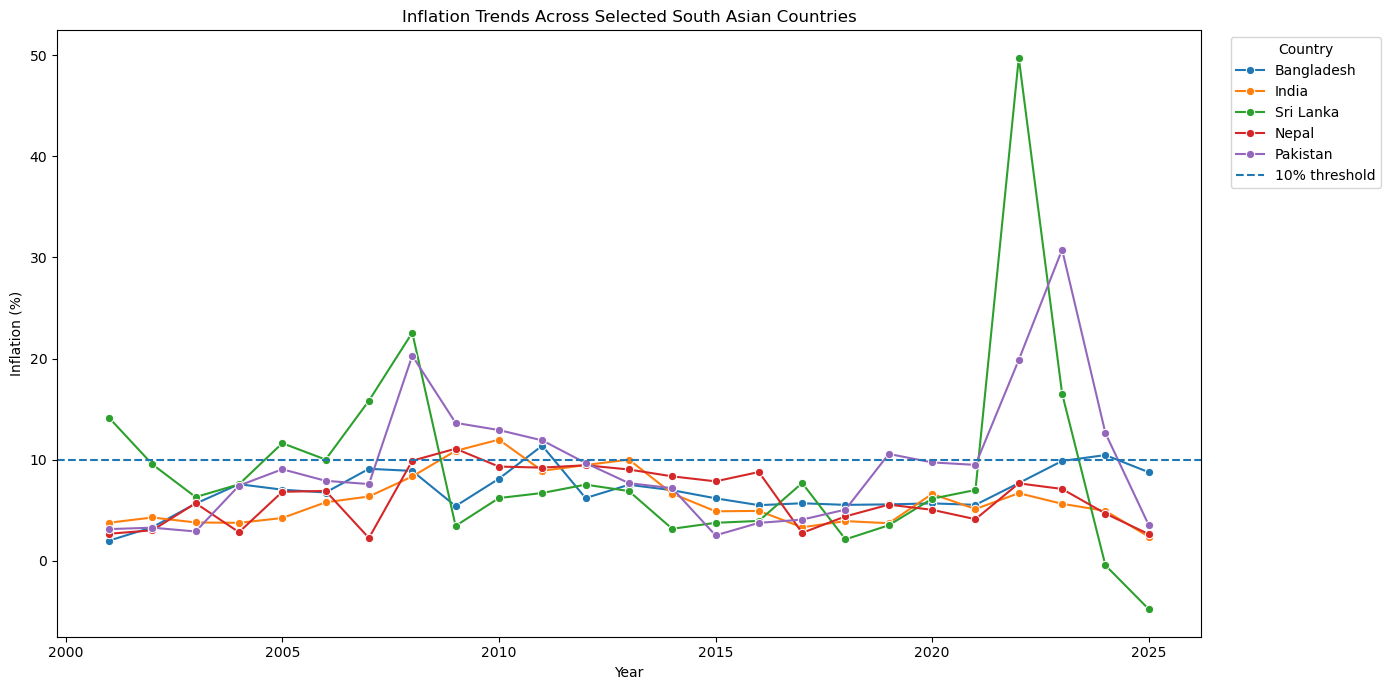

In [44]:
plt.figure(figsize=(14, 7))

sns.lineplot(
    data=df_long,
    x="Year",
    y="Inflation",
    hue="Country Name",
    marker="o"
)

plt.axhline(
    y=10,
    linestyle="--",
    label="10% threshold"
)

plt.title("Inflation Trends Across Selected South Asian Countries")
plt.xlabel("Year")
plt.ylabel("Inflation (%)")
plt.legend(title="Country", bbox_to_anchor=(1.02, 1), loc="upper left")

plt.tight_layout()
plt.show()

# Key Findings

## Overall Findings

The analysis of inflation trends across Pakistan, India, Bangladesh,
Sri Lanka, and Nepal from 2000 to 2025 produced several important
findings.

### 1. Pakistan had the highest average inflation

Pakistan recorded the highest average inflation among the five selected
countries at approximately 9.47% during the study period.

### 2. Sri Lanka experienced the greatest inflation volatility

Sri Lanka recorded inflation volatility of approximately 10.20,
substantially higher than the other selected countries.

### 3. Sri Lanka experienced the highest inflation peak

Sri Lanka's inflation reached approximately 49.72% in 2022, representing
the highest annual inflation rate observed among the selected countries.

### 4. Pakistan experienced a major inflation episode in 2022–2024

Pakistan's inflation increased substantially during this period, reaching
a peak of approximately 30.77% in 2023.

### 5. Pakistan experienced several periods of double-digit inflation

Pakistan recorded inflation above 10% in eight years during the study
period, including 2008, 2009, 2010, 2011, 2019, 2022, 2023, and 2024.

### 6. Inflation patterns differed considerably across countries

The comparison shows that the timing and magnitude of inflation episodes
varied across the selected South Asian economies.

### 7. Inflation rates showed relationships across some countries

The correlation analysis indicates that inflation movements were
positively related for some country pairs, although the strength of the
relationship varied.

# Economic Interpretation

The analysis demonstrates that inflation patterns differed considerably
across the selected South Asian economies.

Pakistan's relatively high average inflation indicates that price
pressures were persistent over the study period. The country's high
inflation volatility also indicates substantial variation in inflation
from year to year.

Sri Lanka stands out because of the combination of relatively high
average inflation, very high volatility, and an exceptional inflation
peak in 2022.

The differences between countries suggest that inflation is influenced
by both broader regional conditions and country-specific economic
factors.

The correlation analysis provides evidence that inflation movements
sometimes occurred in similar directions across countries. However,
correlation alone cannot establish causal relationships.

Further analysis using variables such as exchange rates, food prices,
energy prices, interest rates, GDP growth, and money supply would be
required to investigate the underlying causes of these inflation
patterns.

# Limitations

- The analysis uses CPI data and focuses primarily on inflation trends;
  it does not directly examine the causes of inflation.

- The study covers selected South Asian countries rather than all
  countries in the region.

- Correlation analysis identifies relationships between variables but
  does not establish causation.

- Differences in economic structures, policies, and data availability
  across countries may affect comparisons.

- Additional economic indicators would be required for a more detailed
  explanation of inflation drivers.

# Conclusion

This project used Python to analyze inflation and consumer price trends
across Pakistan, India, Bangladesh, Sri Lanka, and Nepal from 2000 to
2025.

The analysis included data cleaning, transformation of CPI data,
calculation of year-over-year inflation, exploratory data analysis,
country comparisons, inflation volatility analysis, identification of
high-inflation periods, and correlation analysis.

Pakistan recorded the highest average inflation among the selected
countries, while Sri Lanka experienced the greatest inflation volatility
and the highest inflation peak.

The analysis also identified several periods of elevated inflation in
Pakistan, particularly during 2022–2024.

Overall, the project demonstrates how Python-based data analysis can be
used to transform economic data into meaningful insights. It also
highlights the value of combining data analytics skills with economic
knowledge when interpreting real-world economic trends.